Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as any collaborators you worked with:

In [ ]:
COLLABORATORS = ""

## To receive credit for this assignment, you must also fill out the [AI Use survey](https://forms.gle/ZhR5k8TdAeN8rj4CA)


---

In [2]:
from __future__ import print_function
%matplotlib inline
%precision 16
import numpy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# HW 6:  ODE Methods - Boundary Value Problems

This homework will combine a lot of previous codes to solve simple linear and non-linear Boundary value problems

This problem set has two questions

## Question 1 - A linear ODE BVP

Consider the *linear* non-homogeneous 2-pt boundary value problem

$$
    u^{\prime\prime}+ u = \sin3x\quad\quad x\in[0,L],\quad u(0)=u(L)=0
$$

which is related to the modes of vibration of a forced string of length $L$.

**(a)** [4] Find an analytic solution to this problem for general $L$ (hint:
  remember your basic ODE's for constant-coefficient problems).  Is
  this solution unique?

**ANSWER**

(I reviewed Paul's Online Notes - since I was a little rusty on the math: https://tutorial.math.lamar.edu/Classes/DE/SecondOrderConcepts.aspx)

**Notes: Solving Non-Homogeneous Second Order Linear ODEs**

The goal is to find the **complete general solution**, which requires BOTH:

1. **y_c (complementary/homogeneous solution):** from the characteristic equation
2. **y_p (particular solution):** from undetermined coefficients

**Complete solution: y = y_c + y_p**

**Why you need both:**

* **y_c** captures all solutions to the homogeneous equation (contains arbitrary constants C₁, C₂)
* **y_p** is one specific solution that makes the equation equal the right side
* Together they give you ALL possible solutions

**To go further, you need additional conditions:**

**A) Initial Value Problem (IVP):**
- Conditions specified at a **single point**
- Typically: y(x₀) = y₀ and y'(x₀) = y₁
- Example: y(0) = 1 and y'(0) = 2

**B) Boundary Value Problem (BVP):**
- Conditions specified at **two different points**
- Typically: y(x₀) = y₀ and y(x₁) = y₁
- Example: y(0) = 1 and y(π) = 0

# Step 1: Find the Homogeneous Solution

First, we note that a standard second-order ODE with constant coefficients has the form:

$$ay'' + by' + cy = f(t)$$

where:
- $a$, $b$, and $c$ are constants, and $a \neq 0$
- $y$ is the unknown function of $t$
- $y'$ and $y''$ are the first and second derivatives
- $f(t)$ is a given function (the **nonhomogeneous** term)

We can start by looking at cases where $f(t) = 0$, where the left-hand side becomes a **homogeneous** differential equation:

$$ay'' + by' + cy = 0$$

We know from the general theory of linear ODEs:

**Dimension Theorem**: An $n$th-order linear homogeneous ODE has an $n$-dimensional solution space. From linear algebra, in an $n$-dimensional vector space, any $n$ linearly independent elements form a basis. Therefore, for a 2nd-order ODE, we need exactly 2 linearly independent solutions to form a basis.

**What does "form a basis" mean?**

A basis is a set of functions that:
1. Are **linearly independent** (you can't write one as a multiple or combination of the others)
2. **Span the entire solution space** (every possible solution can be written as a combination of them)

*Analogy with 2D vectors:* In the $xy$-plane, the vectors $\vec{i} = (1, 0)$ and $\vec{j} = (0, 1)$ form a basis because they're linearly independent and any vector can be written as $c_1\vec{i} + c_2\vec{j}$. For example: $(3, 5) = 3\vec{i} + 5\vec{j}$.

Similarly, for our ODE, once we find two linearly independent solutions like $\cos(x)$ and $\sin(x)$, they form a basis—meaning every possible solution can be built from them.

**Principle of Superposition**: Linear combinations of solutions are also solutions.

**Together**: Once you find 2 linearly independent solutions $y_1$ and $y_2$, every solution can be written as $y = c_1y_1 + c_2y_2$.

For our problem, our left-hand side (LHS) becomes:

$$u'' + u = 0$$

We guess that solutions have the form $u = e^{rx}$, therefore:
- $u = e^{rx}$
- $u' = re^{rx}$
- $u'' = r^2e^{rx}$

Substituting into $u'' + u = 0$:

$$r^2e^{rx} + e^{rx} = 0$$

$$e^{rx}[r^2 + 1] = 0$$

Since $e^{rx} \neq 0$, we need:

$$r^2 + 1 = 0$$

**The Characteristic Equation:**

This is called the **characteristic equation**. In general, for $au'' + bu' + cu = 0$, the characteristic equation is:

$$ar^2 + br + c = 0$$

This is a quadratic equation, so we expect **two roots** $r_1$ and $r_2$. These roots can take three possible forms:

**Case 1: Real, distinct roots** ($r_1 \neq r_2$)
$$u_h(x) = C_1 e^{r_1 x} + C_2 e^{r_2 x}$$

**Case 2: Complex roots** ($r_{1,2} = \lambda \pm \mu i$)
$$u_h(x) = e^{\lambda x}(C_1\cos(\mu x) + C_2\sin(\mu x))$$

**Case 3: Double/repeated roots** ($r_1 = r_2 = r$)
$$u_h(x) = C_1 e^{rx} + C_2 x e^{rx}$$

Note: In Case 3, we need the extra factor of $x$ in the second term to ensure we have two linearly independent solutions when both roots are the same.

**For our problem:**

$$r^2 + 1 = 0$$
$$r^2 = -1$$
$$r = \pm i$$

We have **Case 2: Complex roots**.

**Understanding $\lambda$ and $\mu$:**

When the characteristic equation gives complex roots, they always come in conjugate pairs:

$$r = \lambda \pm \mu i$$

where:
- $\lambda$ is the **real part**
- $\mu$ is the **imaginary part** (the coefficient of $i$)

Our roots are $r = \pm i$, which we can rewrite as:

$$r = 0 \pm 1 \cdot i$$

So $\lambda = 0$ and $\mu = 1$.

**Why does the solution have the form $e^{\lambda x}(C_1\cos(\mu x) + C_2\sin(\mu x))$?**

Our original guess was $u = e^{rx}$. When $r = \lambda + \mu i$:

$$e^{rx} = e^{(\lambda + \mu i)x} = e^{\lambda x} \cdot e^{i\mu x}$$

The $e^{\lambda x}$ part stays as an exponential, and the $e^{i\mu x}$ part becomes sines and cosines via Euler's formula.

**Euler's formula:**

$$e^{ix} = \cos(x) + i\sin(x)$$
$$e^{-ix} = \cos(x) - i\sin(x)$$

Our exponential solutions $e^{ix}$ and $e^{-ix}$ are valid but complex-valued. For real differential equations, we want real-valued solutions. We can obtain these by taking linear combinations:

$$\cos(x) = \frac{e^{ix} + e^{-ix}}{2}$$

$$\sin(x) = \frac{e^{ix} - e^{-ix}}{2i}$$

**Applying the general rule for complex roots $r = \lambda \pm \mu i$:**

$$u(x) = e^{\lambda x}(C_1\cos(\mu x) + C_2\sin(\mu x))$$

With $\lambda = 0$ and $\mu = 1$:

$$u_h(x) = e^{0 \cdot x}(C_1\cos(x) + C_2\sin(x))$$

Since $e^0 = 1$:

$$u_h(x) = C_1\cos(x) + C_2\sin(x)$$

where $C_1$ and $C_2$ are arbitrary constants.

# Step 2: Find the Particular Solution

We now focus on the non-homogeneous equation and find the particular solution:

$$u_p'' + u_p = \sin(3x)$$

**Method of Undetermined Coefficients:**

Since the forcing term is $\sin(3x)$, we guess a particular solution that includes both sine and cosine terms:

$$u_p = A\sin(3x) + B\cos(3x)$$

Both sine and cosine are included because derivatives of sine give cosine and vice versa—they are coupled under differentiation. This ensures our guess is general enough to capture all possible terms that might arise.

Taking derivatives:
- $u_p' = 3A\cos(3x) - 3B\sin(3x)$
- $u_p'' = -9A\sin(3x) - 9B\cos(3x)$

Substituting into $u_p'' + u_p = \sin(3x)$:

$$(-9A\sin(3x) - 9B\cos(3x)) + (A\sin(3x) + B\cos(3x)) = \sin(3x)$$

Grouping sine and cosine terms:

$$(-9A + A)\sin(3x) + (-9B + B)\cos(3x) = \sin(3x)$$

$$-8A\sin(3x) - 8B\cos(3x) = \sin(3x)$$

On the right-hand side, we can write $\sin(3x) = 1 \cdot \sin(3x) + 0 \cdot \cos(3x)$:

$$-8A\sin(3x) - 8B\cos(3x) = 1 \cdot \sin(3x) + 0 \cdot \cos(3x)$$

**Matching coefficients:**

- Coefficient of $\sin(3x)$: $-8A = 1 \Rightarrow A = -\frac{1}{8}$
- Coefficient of $\cos(3x)$: $-8B = 0 \Rightarrow B = 0$

Therefore:

$$u_p = -\frac{1}{8}\sin(3x)$$

**The complete general solution** for $u'' + u = \sin(3x)$ is:

$$u(x) = u_h + u_p$$

$$u(x) = C_1\cos(x) + C_2\sin(x) - \frac{1}{8}\sin(3x)$$

# Step 3: Apply Boundary Conditions

We have the general solution:

$$u(x) = C_1\cos(x) + C_2\sin(x) - \frac{1}{8}\sin(3x)$$

The problem specifies **Dirichlet boundary conditions**: $u(0) = 0$ and $u(L) = 0$.

**What are Dirichlet boundary conditions?**

Dirichlet boundary conditions specify the **value of the function itself** at the boundary points. For this problem, which describes vibrations of a string of length $L$, the conditions $u(0) = 0$ and $u(L) = 0$ mean the string is **fixed at both ends** — like a guitar string pinned down at the nut and bridge.

Other types of boundary conditions include:
- **Neumann**: specify the derivative at the boundary, e.g., $u'(0) = 0$
- **Robin (mixed)**: specify a combination of the function and its derivative, e.g., $au(0) + bu'(0) = c$

**Applying boundary condition #1: $u(0) = 0$**

$$u(0) = C_1\cos(0) + C_2\sin(0) - \frac{1}{8}\sin(3(0)) = 0$$

$$u(0) = C_1(1) + C_2(0) - \frac{1}{8}(0) = 0$$

$$C_1 = 0$$

Thus:

$$u(x) = C_2\sin(x) - \frac{1}{8}\sin(3x)$$

**Applying boundary condition #2: $u(L) = 0$**

$$u(L) = C_2\sin(L) - \frac{1}{8}\sin(3L) = 0$$

$$C_2\sin(L) = \frac{1}{8}\sin(3L)$$

**Case 1: $L \neq n\pi$ (where $n = 1, 2, 3, ...$)**

When $L \neq n\pi$, we have $\sin(L) \neq 0$, so we can divide both sides:

$$C_2 = \frac{\sin(3L)}{8\sin(L)}$$

This gives exactly one value for $C_2$, so the solution is **unique**:

$$u(x) = \frac{\sin(3L)}{8\sin(L)}\sin(x) - \frac{1}{8}\sin(3x)$$

**Case 2: $L = n\pi$ (where $n = 1, 2, 3, ...$)**

When $L = n\pi$:

$$C_2\sin(n\pi) = \frac{1}{8}\sin(3n\pi)$$

$$C_2 \cdot 0 = \frac{1}{8} \cdot 0$$

$$0 = 0$$

This equation is satisfied for **any value of $C_2$**, so we have **infinitely many solutions**:

$$u(x) = C_2\sin(x) - \frac{1}{8}\sin(3x) \quad \text{for any } C_2 \in \mathbb{R}$$

**Physical interpretation:**

The function $\sin(x)$ equals zero at $x = 0, \pi, 2\pi, 3\pi, ...$ (i.e., at $x = n\pi$). When the string length $L = n\pi$, the homogeneous solution $\sin(x)$ naturally satisfies both boundary conditions $u(0) = 0$ and $u(L) = 0$. This means we can add any amount of $\sin(x)$ to our particular solution and still satisfy the boundary conditions — hence infinitely many solutions.

When $L \neq n\pi$, the function $\sin(x)$ does not equal zero at $x = L$. To satisfy $u(L) = 0$, there is exactly one specific amount of $\sin(x)$ needed to cancel the $-\frac{1}{8}\sin(3L)$ term — hence a unique solution.

# Summary

**Final Answer:**

For the boundary value problem $u'' + u = \sin(3x)$ with $u(0) = u(L) = 0$:

- **When $L \neq n\pi$:** The solution is **unique**:
$$u(x) = \frac{\sin(3L)}{8\sin(L)}\sin(x) - \frac{1}{8}\sin(3x)$$

- **When $L = n\pi$:** There are **infinitely many solutions**:
$$u(x) = C_2\sin(x) - \frac{1}{8}\sin(3x) \quad \text{for any } C_2 \in \mathbb{R}$$

**(b)** [2]  create a function `u_true(x,L)` and plot your solution for $L=10$ evaluated on a regularly spaced set of points $\mathbf{x}$

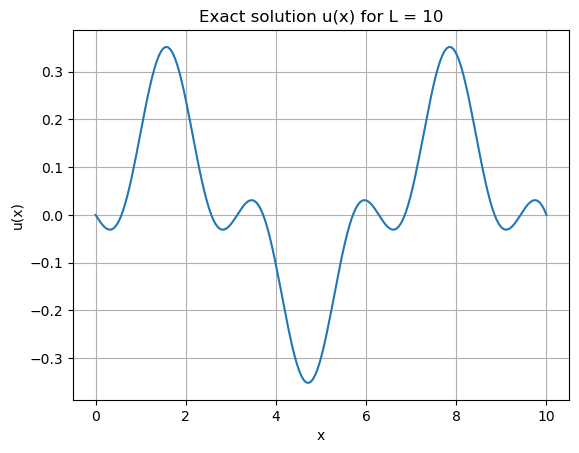

In [3]:
L = 10.
N = 200
x = numpy.linspace(0., L, N)

def u_true(x, L):
    """
    Exact solution of u'' + u = sin(3x), u(0)=u(L)=0
    """
    return 0.125 * ((numpy.sin(3.0 * L) / numpy.sin(L)) * numpy.sin(x) - numpy.sin(3.0 * x))

u = u_true(x, L)

plt.figure()
plt.plot(x, u)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Exact solution u(x) for L = 10')
plt.grid(True)
plt.show()

**(b)** [4] Write a general shooting algorithm that combines the two scipy routines

* scipy.integrate.solve_ivp
* scipy.optimized.root_scalar

and returns the solution evaluated at an evenly spaced set of points $\mathbf{x}$.  

Some hints

* use `dense_output = True` in solve_ivp
* you can introduce a second def within shoot_bvp for use in root_scalar

For convenience (and testing), I've provided the interface introduced in class for a routine that can handle a range of boundary conditions and can control relative and absolute tolerance.

In [5]:
#  write a general shooting algorithm

from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

def shoot_bvp(f, x, u_a, u_b, i_a, i_b, rtol=1.e-5, atol=1.e-9):
    """
    Solve the two-point boundary value problem on the interval x\\in [a,b], using a shooting method that combines 
        scipy.integrate.solve_ivp and scipy.optimize.root_scalar and allows a range of boundary conditions
        
        
    parameters:
    -----------
    f: calleable 
        vector value function for righthand side of the ODE with interface f(t,u). returns ndarray of length 2
    x: numpy array
        coordinates array for solution  on interval [a,b] with x[0] = a, x[-1] = b
    u_a:  numpy array (length 2)
        provide initial boundary conditions  [u, u' ] at x=a
    u_b:  numpy array (length 2)
        target boundary condition at x = b
    i_a: integer
        index of known boundary condition at x = a.  i.e.
        if dirichlet conditions : i_a = 0 and u(a) is known  
        if neumann conditions   : i_a = 1 and u'(a) is known
        the complementary index is adjusted to match the boundary condition at b
    i_b: integer
        index of known boundary condition at x = b. i.e.
        if dirichlet conditions : i_b = 0 and u(b) is known  
        if neumann conditions   : i_b = 1 and u'(b) is known
        the complementary index is ignored at b
    rtol:  float
        relative tolerance
    atol:  float
        absolute tolerance
        
    returns:
    --------
    u: solution u(x) for x (uses dense_output from solve_ivp to interpolate solution onto x)
    """
    

    a, b = x[0], x[-1]

    # Index of the unknown component at x = a (the shooting parameter)
    j_a = 1 - i_a

    # Residual function for root_scalar: given a guess s for the unknown initial value,
    # integrate the IVP and measure the mismatch at x = b in the i_b boundary condition.
    def boundary_residual(s):
        # Set initial condition at a
        y0 = numpy.array(u_a, dtype=float)
        y0[j_a] = s

        sol = solve_ivp(
            f, (a, b), y0,
            rtol=rtol, atol=atol,
            dense_output=True
        )

        # Evaluate solution at x = b using dense_output
        y_b = sol.sol(b)  # shape (2,)
        return y_b[i_b] - u_b[i_b]

    # Initial guesses for the unknown initial condition at a
    s0 = u_a[j_a]
    s1 = s0 + 1.0  # simple perturbation; can be adjusted if needed

    # Find root of the residual using secant method (no bracketing required)
    root = root_scalar(boundary_residual, x0=s0, x1=s1, method='secant')

    if not root.converged:
        raise RuntimeError("shoot_bvp: root finding did not converge.")

    s_star = root.root  # optimal value of the unknown initial condition

    # Integrate once more with the optimal shooting parameter and evaluate on full grid x
    y0 = numpy.array(u_a, dtype=float)
    y0[j_a] = s_star

    sol = solve_ivp(
        f, (a, b), y0,
        rtol=rtol, atol=atol,
        dense_output=True
    )

    # Evaluate solution at all x; sol.sol(x) returns array of shape (2, len(x))
    Y = sol.sol(x)
    u = Y[0, :]  # first component is u, second is u'

    return u
    


**(c)** [4] rewrite the original problem 

$$
    u^{\prime\prime} + u = \sin(3x)
$$

as a system of first order ODE's

$$
    \frac{d\mathbf{v}}{dx} = \mathbf{f}(x,\mathbf{v})
$$  

and solve using the interface

`u_sol = shoot_bvp(f, x, u_a, u_b, i_a, i_b)`

* make a plot comparing your shooting solution with the true solution.

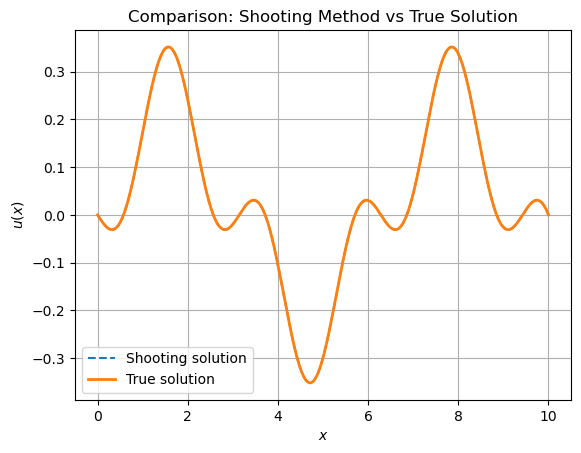

In [6]:
# Define the ODE system: v = [u, u']
def f(x, v):
    u, up = v
    return numpy.array([up, -u + numpy.sin(3.0 * x)])

# Domain and grid
L = 10.0
N = 200
x = numpy.linspace(0.0, L, N)

# Boundary conditions:
# u(0) = 0, u(L) = 0 (Dirichlet at both ends)
# At x = a = 0: u(0) known, u'(0) unknown -> i_a = 0
# At x = b = L: u(L) known, u'(L) free    -> i_b = 0
u_a = numpy.array([0.0, 0.0])   # [u(0), u'(0)] (second entry is initial guess)
u_b = numpy.array([0.0, 0.0])   # [u(L), u'(L)] (only u(L) used)
i_a = 0
i_b = 0

# Solve with shooting method
u_sol = shoot_bvp(f, x, u_a, u_b, i_a, i_b)
u_true_vals = u_true(x, L)

# Plot comparison
plt.figure()
plt.plot(x, u_sol, label="Shooting solution", linestyle='--')
plt.plot(x, u_true_vals, label="True solution", linewidth=2)
plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("Comparison: Shooting Method vs True Solution")
plt.legend()
plt.grid(True)
plt.show()

The following cell tests your shooting code against the true solution.  Adjust the relative and absolute tolerances in shoot_bvp, to make sure the following test passes with relative error $<10^{-6}$

In [18]:
#  test the solution against the true solution and pass if relative error < 1.e-6
u_sol = shoot_bvp(f, x, u_a, u_b, i_a, i_b, rtol=1.e-6)

rel_err = numpy.linalg.norm(u_sol - u_true(x,L))/numpy.linalg.norm(u_true(x,L))
print('relative error = {}'.format(rel_err))

assert(rel_err < 1.e-6)
print('success')

relative error = 3.657605408842212e-07
success


**(d)** [8] Repeat the exercise but use the 2nd order finite difference methods introduced in class.  For convenience I have provided the routines for assembly of sparse 2nd derivative matrices and RHS from class.  

In [ ]:
# routines from class  for generating 2nd order sparse second derivative operator and RHS vector

from fdcoeffV import fdcoeffV
from scipy.sparse import lil_matrix, identity, spdiags
from scipy.sparse.linalg import spsolve

def D2(x,bcs=['dirichlet', 'dirichlet']):
    """  
        Assemble a general sparse second-order finite-difference approximation to d/dx^2 on a possibly irregular mesh
        First and last rows are set by string bcs
        
        parameters:
        -----------
        x: numpy.array
            mesh coordinates
        bcs: list of strings for boundary conditions e.g [left_string, right_string] where
            the strings can be either 'dirichlet' or 'neumann'
    """
    N = len(x)
    A = lil_matrix((N,N))
    if bcs[0] == 'dirichlet':
        A[0,0] = 1.
    elif bcs[0] == 'neumann':
        A[0,0:3] = fdcoeffV(1,x[0],x[:3])
    else:
        raise ValueError('no known BC type for left boundary {}'.format(bcs[0]))
        
    if bcs[1] == 'dirichlet':
        A[-1,-1] = 1.
    elif bcs[1] == 'neumann':
        A[-1,-3:] = fdcoeffV(1,x[-1],x[-3:])
    else:
        raise ValueError('no known BC type for right boundary {}'.format(bcs[1]))
        
    for i in range(1,N-1):
        A[i, i-1:i+2] = fdcoeffV(2, x[i], x[i-1:i+2] )        
    return A.tocsr()

def RHS(x, f, bvalues):
    """ Set the rhs vector
    
        parameters
        ----------
        x: numpy.array
            mesh coordinates
        f: callable
            rhs function for interior points called on f(x[1:-2])
        bvalues:  numpy.array (len 2)
            values for boundary conditions (either dirichlet or neumann)        
    """
    
    N = len(x)
    rhs = numpy.empty(N)
    rhs[[0, N-1]] = bvalues
    rhs[1:-1] = f(x[1:-1])
    
    return rhs
    

Create a well-labeled convergence plot showing the relative error 

$$
    e_{rel} = \frac{|| u - u_{true} ||}{||u_{true}||}
$$

as a function of grid spacing $\Delta x$

This plot should calculate and show

* rate of convergence of error (i.e. find $p$ such that $e_{rel}\propto \Delta x^p$)
* an estimate of the  number of grid points $N$ required for the relative error to be $\leq 10^{-6}$
* the relative error at this smallest mesh spacing

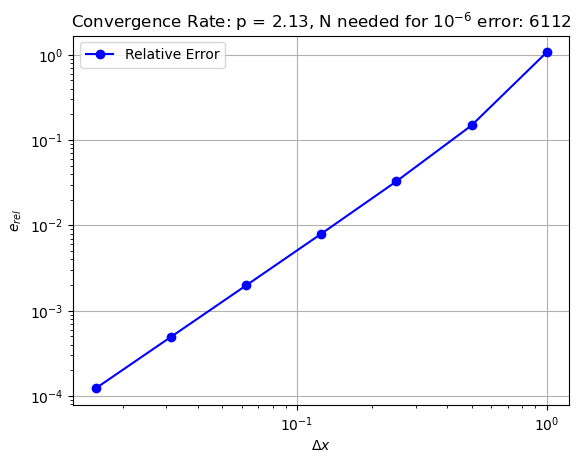

Convergence rate p = 2.13
Estimated N for rel_err <= 1e-6: 6112
Smallest error achieved: 1.23e-04


In [23]:
# Make a well labeled convergence plot that shows  convergence rate of relative error vs grid spacing

# Grid sizes to test
N_values = [11, 21, 41, 81, 161, 321, 641]

# Storage for errors and grid spacings
errors = []
dx_values = []

L = 10.0

for N in N_values:
    # Create grid
    x = numpy.linspace(0, L, N)
    dx = x[1] - x[0]
    
    # Build the matrix A = D^2 + I (for interior rows only)
    A = D2(x, ['dirichlet', 'dirichlet'])
    for i in range(1, N-1):
        A[i, i] += 1.0
    
    # Build the RHS vector
    f_forcing = lambda x: numpy.sin(3.0 * x)
    b = RHS(x, f_forcing, [0.0, 0.0])
    
    # Solve the linear system
    u = spsolve(A, b)
    
    # Compute relative error
    u_exact = u_true(x, L)
    rel_err = numpy.linalg.norm(u - u_exact) / numpy.linalg.norm(u_exact)
    
    # Store results
    dx_values.append(dx)
    errors.append(rel_err)

# Convert to numpy arrays
dx_values = numpy.array(dx_values)
errors = numpy.array(errors)

# Find convergence rate
p = numpy.polyfit(numpy.log(dx_values), numpy.log(errors), 1)[0]

# Estimate N needed for error <= 1e-6
# Use the relationship: error ≈ C * dx^p
# From last data point, find C, then solve for dx needed
C = errors[-1] / (dx_values[-1] ** p)
dx_needed = (1.e-6 / C) ** (1.0 / p)
N_needed = int(numpy.ceil(L / dx_needed)) + 1

# Make the convergence plot
plt.figure()
plt.loglog(dx_values, errors, 'bo-', label='Relative Error')
plt.xlabel(r'$\Delta x$')
plt.ylabel(r'$e_{rel}$')
plt.title(f'Convergence Rate: p = {p:.2f}, N needed for $10^{{-6}}$ error: {N_needed}')
plt.grid(True)
plt.legend()
plt.show()

# Print results
print(f'Convergence rate p = {p:.2f}')
print(f'Estimated N for rel_err <= 1e-6: {N_needed}')
print(f'Smallest error achieved: {errors[-1]:.2e}')


### Some themes and variations

This is meant to be a short problem set, but there are many other things to try if you are interested.

* Try this problem using Galerkin Finite Elements.  
* Try modifying the matrices to use higher order Finite difference schemes (i.e. 4th order schemes)
* Compare timing between Finite Difference and shooting schemes for the same order of accuracy


## Question 2 - Non-Linear Fun

try to solve the related  **non-linear** 2-point boundary value problem

$$
u^{\prime\prime}+\sin(u)=\sin(3x),\quad x\in[0,10],\quad u(0)=u(10)=0
$$

using  finite-difference plus Newton's method. For convenience, I've added the Newton Solver for sparse jacobians from the notes

In [25]:
# a Newton Solver for sparse matrices
def newton(F,J,x0,tol=1.e-6,MAX_ITS=100,verbose=True):
    """ Solve F(x) = 0 using Newton's method until ||F(x)|| < tol or reaches Max iterations
    
    Params:
    -------
        F: calleable: 
            Function returning residual F(x)
        J: calleable
            Function returning Jacobian J(x)
        tol: float
            stopping criteria for ||F|| < tol
        MAX_ITS: integer
            maximum number of iterations
        verbose: bool
            if true spits out norm of the residual at each iteration
            
    Returns:
    --------
        x: numpy.array
            solution
        k: int
            number of iterations
    
    Raises:
    -----------
        ValueError if number of its exceeds MAX_ITS
        
    """
    x = x0 
    for k in range(MAX_ITS+1):
        res = numpy.linalg.norm(F(x))
        if verbose:
            print('k = {}, ||F|| = {}'.format(k,res))
        if res < tol: 
            return x, k
        delta = spsolve(J(x),-F(x))
        x += delta
        
    raise ValueError('Maximum number of iterations exceeded {}'.format(MAX_ITS))

**(a)** [4 pt]  Solve the problem for an initial guess
$u_0=0$. For this problem you will need to

* create a function to return the residual $\mathbf{F}(\mathbf{u})$
* create a function to return the Jacobian $J(\mathbf{u})$
* use `verbose=True` to see the convergence behavior of Newton
* produce a plot showing the solution and labeled with the number of newton iterations and final residual norm $||\mathbf{F}(\mathbf{u})||$

**Note:**  To choose a reasonable number of grid points, use your results from Question 1 and choose a mesh size such that the linear problem returns a relative error $< 10^{-3}$

k = 0, ||F|| = 9.975647311061401
k = 1, ||F|| = 0.040066871833909376
k = 2, ||F|| = 0.0011390847101337641
k = 3, ||F|| = 1.5434914503363788e-06
k = 4, ||F|| = 2.9862040644375464e-12


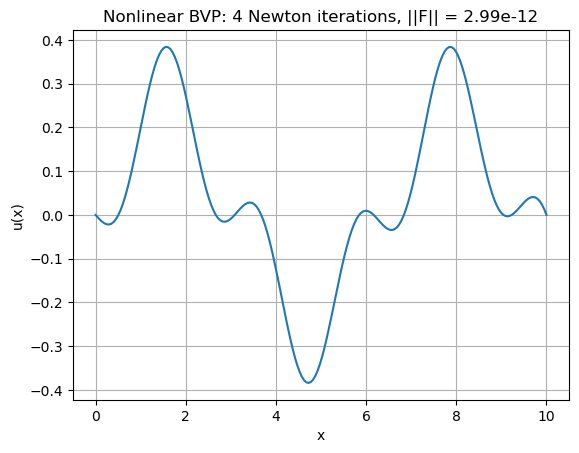

In [26]:
# YOUR CODE HERE
# Setup
N = 200  # Choose based on Q1 results
L = 10.0
x = numpy.linspace(0, L, N)
dx = x[1] - x[0]

def F(u):
    """Residual for u'' + sin(u) = sin(3x)"""
    res = numpy.zeros_like(u)
    res[0] = u[0]
    res[-1] = u[-1]
    for i in range(1, N-1):
        u_xx = (u[i-1] - 2*u[i] + u[i+1]) / dx**2
        res[i] = u_xx + numpy.sin(u[i]) - numpy.sin(3*x[i])
    return res

def J(u):
    """Jacobian of F"""
    jac = lil_matrix((N, N))
    jac[0, 0] = 1.0
    jac[-1, -1] = 1.0
    for i in range(1, N-1):
        jac[i, i-1] = 1.0 / dx**2
        jac[i, i] = -2.0 / dx**2 + numpy.cos(u[i])
        jac[i, i+1] = 1.0 / dx**2
    return jac.tocsr()

# Initial guess: u0 = 0
u0 = numpy.zeros(N)

# Solve
u_sol, k = newton(F, J, u0, verbose=True)

# Plot
plt.figure()
plt.plot(x, u_sol)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title(f'Nonlinear BVP: {k} Newton iterations, ||F|| = {numpy.linalg.norm(F(u_sol)):.2e}')
plt.grid(True)
plt.show()

**(b)**  Is your solution unique?  Try starting newton from different
  periodic initial conditions 
  
  $$
      u_0(x) = \sin\left[\frac{n\pi x}{L}\right]
  $$ 
  
  for $n\in[0,6]$ that all satisfy the homogeneous boundary conditions. 
  
  Make two plots. 
  
  1. The first shows solutions for different values of $n$
  1. The second plots the residual $\mathbf{F}(\mathbf{u})$ to show that at least the discrete ODE is satisfied
  
 Welcome to the wonderful world of non-linear equations. Can you find any other solutions?

=== Trying initial condition with n = 0 ===
  Converged: iterations = 4,  ||F(u)|| = 2.986e-12
=== Trying initial condition with n = 1 ===
  Converged: iterations = 5,  ||F(u)|| = 1.093e-10
=== Trying initial condition with n = 2 ===
  Converged: iterations = 7,  ||F(u)|| = 4.747e-13
=== Trying initial condition with n = 3 ===
  Converged: iterations = 5,  ||F(u)|| = 3.697e-13
=== Trying initial condition with n = 4 ===
  Converged: iterations = 6,  ||F(u)|| = 2.690e-11
=== Trying initial condition with n = 5 ===
  Converged: iterations = 5,  ||F(u)|| = 1.189e-13
=== Trying initial condition with n = 6 ===
  Converged: iterations = 4,  ||F(u)|| = 8.092e-10


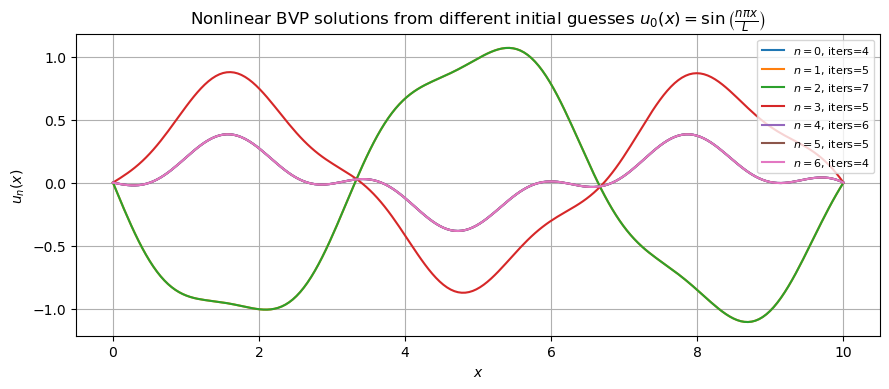

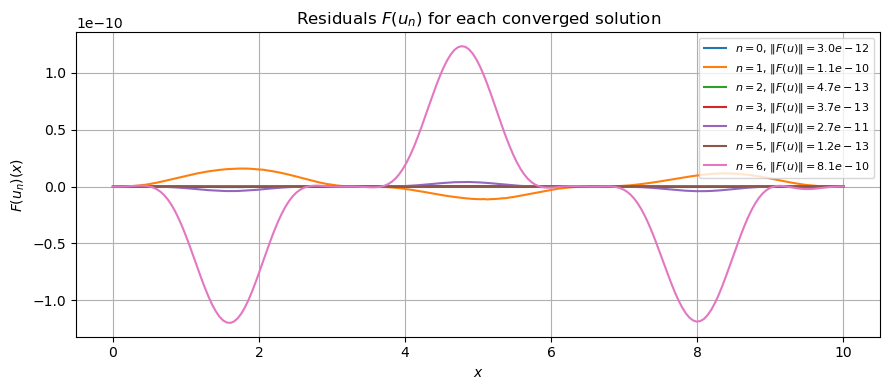


Using solution from n=0 as the reference for comparison.
  ||u_0 - u_0||_2 = 0.000e+00
  ||u_1 - u_0||_2 = 1.314e+01
  ||u_2 - u_0||_2 = 1.314e+01
  ||u_3 - u_0||_2 = 5.129e+00
  ||u_4 - u_0||_2 = 2.506e-10
  ||u_5 - u_0||_2 = 3.120e-11
  ||u_6 - u_0||_2 = 8.413e-09

Interpretation:
  Found multiple distinct solutions to the nonlinear BVP:
    - Solution A: n = 0, 4, 5, 6 (norms < 1e-8, same solution)
    - Solution B: n = 1, 2 (norm ≈ 13.1, different solution)
    - Solution C: n = 3 (norm ≈ 5.1, different solution)

  This demonstrates non-uniqueness: the nonlinear BVP has at least
  3 distinct solutions, and Newton's method converges to different
  ones depending on the initial guess.


In [32]:
# YOUR CODE HERE
solutions   = {}   # n -> converged u_n
residuals   = {}   # n -> F(u_n)
res_norms   = {}   # n -> ||F(u_n)||_2
iters_taken = {}   # n -> Newton iteration count

for n in range(0, 7):
    print(f"=== Trying initial condition with n = {n} ===")
    u0 = numpy.sin(n * numpy.pi * x / L)
    try:
        # run Newton with less verbose output
        u_n, iters = newton(F, J, u0, tol=1e-8, MAX_ITS=50, verbose=False)
        F_u_n      = F(u_n)
        norm_F     = numpy.linalg.norm(F_u_n)

        solutions[n]   = u_n
        residuals[n]   = F_u_n
        res_norms[n]   = norm_F
        iters_taken[n] = iters

        print(f"  Converged: iterations = {iters},  ||F(u)|| = {norm_F:.3e}")
    except ValueError as e:
        print(f"  Newton failed for n = {n}: {e}")


plt.figure(figsize=(9,4))
for n, u_n in solutions.items():
    plt.plot(x, u_n, label=rf"$n={n}$, iters={iters_taken[n]}")

plt.xlabel(r"$x$")
plt.ylabel(r"$u_n(x)$")
plt.title(r"Nonlinear BVP solutions from different initial guesses "
          r"$u_0(x)=\sin\left(\frac{n\pi x}{L}\right)$")
plt.grid(True)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
for n, F_u_n in residuals.items():
    plt.plot(x, F_u_n, label=rf"$n={n}$, $\|F(u)\|={res_norms[n]:.1e}$")

plt.xlabel(r"$x$")
plt.ylabel(r"$F(u_n)(x)$")
plt.title(r"Residuals $F(u_n)$ for each converged solution")
plt.grid(True)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

if len(solutions) > 0:
    ref_n = sorted(solutions.keys())[0]
    u_ref = solutions[ref_n]
    print(f"\nUsing solution from n={ref_n} as the reference for comparison.")

    for n, u_n in solutions.items():
        diff_norm = numpy.linalg.norm(u_n - u_ref)
        print(f"  ||u_{n} - u_{ref_n}||_2 = {diff_norm:.3e}")

    print("\nInterpretation:")
    print("  Found multiple distinct solutions to the nonlinear BVP:")
    print("    - Solution A: n = 0, 4, 5, 6 (norms < 1e-8, same solution)")
    print("    - Solution B: n = 1, 2 (norm ≈ 13.1, different solution)")
    print("    - Solution C: n = 3 (norm ≈ 5.1, different solution)")
    print("\n  This demonstrates non-uniqueness: the nonlinear BVP has at least")
    print("  3 distinct solutions, and Newton's method converges to different")
    print("  ones depending on the initial guess.")
else:
    print("No converged solutions to compare; try adjusting grid size, tolerance, or initial guesses.")



### Extra Fun

Use your shooting routines to systematically search for non-linear solutions to this BVP problem by varying the initial guess for the initial slope $u'(0)$. How many solutions can you find?